# Otimização de portfólio pelo modelo de Markowitz

## 1. Modelo de Markowitz

### 1.1 Portfólio de investimentos 

Portfólio de investimentos se refere a uma coleção de ativos financeiros, seja de um fundo de investimentos ou de um investidor individual.

Considerando que temos um conjunto de possíveis ativos financeiros (ações, títulos de renda fixa, modeas, CDBS, LCIS, etc.)

## $$ \{ a_1, a_2, ... , a_n\} $$

um portfólio de investimento pode ser representado por:


### $$ \mathbf{x} = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix} \in \mathbb{R}^n_+ $$

com:

### $$ \sum_{i=1}^{n} x_i = 1 $$

Nesta representação, cada componente $x_i$ do vetor representa a proporção do capital total investida no ativo $a_i$.

In [9]:
import yfinance as yf
import datetime as dt

data_ini = dt.date(  2020,  1,  1  )
data_fim = dt.date(  2024,  12,  31  )

acoes = [
    'VALE3.SA',
    'PETR3.SA',
    'PETR4.SA',
    'ABEV3.SA',
    'SANB11.SA',
    'ITUB4.SA',
    'IBM',
    'GLD',
    'XOM',
    'AAPL',
    'MSFT',
    'TLT',
    'SHY',
]

vals = yf.download( acoes, data_ini, data_fim )[ 'Close' ]
vals

[*********************100%***********************]  13 of 13 completed


Ticker,AAPL,ABEV3.SA,GLD,IBM,ITUB4.SA,MSFT,PETR3.SA,PETR4.SA,SANB11.SA,SHY,TLT,VALE3.SA,XOM
Date,,,,,,,,,,,,,
2020-01-02,72.468262,14.262307,143.949997,100.013763,23.423872,152.505737,9.606692,8.818673,32.112923,74.180817,115.443703,30.140158,53.661720
2020-01-03,71.763725,14.061745,145.860001,99.216110,23.177502,150.606689,9.369454,8.746861,32.094044,74.242134,117.221565,29.918261,53.230305
2020-01-06,72.335571,14.128596,147.389999,99.038879,22.832588,150.996017,9.674058,8.850272,31.225561,74.215858,116.555939,29.740738,53.639008
2020-01-07,71.995354,14.158310,147.970001,99.105331,22.302883,149.619278,9.542259,8.815802,31.159834,74.215858,115.982964,29.957087,53.200024
2020-01-08,73.153496,14.091455,146.860001,99.932518,21.939486,152.002472,9.387027,8.761222,30.916672,74.180817,115.216217,29.962637,52.397755
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,254.120682,11.368768,240.960007,216.340286,24.001295,432.062775,34.957699,31.889343,21.518766,78.672890,83.771706,48.462967,102.536774
2024-12-24,257.037476,NaN,241.440002,218.757843,NaN,436.112854,NaN,NaN,NaN,78.711388,84.125946,NaN,102.633224
2024-12-26,257.853760,11.294340,243.070007,219.225754,24.156691,434.901825,35.515465,32.129070,21.729021,78.730652,84.078056,48.604336,102.720032


In [10]:
import plotly.express as px

fig = px.line ( vals, x = vals.index, y = acoes, title = 'Série hitórica do preço' )
fig.show()

## 1.2 Risco e Retorno

A ideia do Markowitz é encontrar um portfólio balanceado e, para isto, usamos dois conceitos fundamentais:

- Retorno
- Risco

Naturalemnte, um ativo de alto retorno e baixo risco de ve ser preferido a um ativo de baixo retorno e alto risco. Entretando, na meior parte dos casos, ativos de alto retorno possuem risco maior do que ativos de baixo retorno.

O modelo de Markowitz mostra como balancear essas quantidades conflitantes de forma racional dentre todos os portfólio com um mesmo retorno esperado, devemos escolher o de menor risco. 

Oconjunto de pontos que satisfazem o critério de menor risco para um dado retorno é conhecido como fronteira eficiente. 

Os valores de risco e retorno são obtidos através da série histórica dos ativos.

### 1.2.1 Retorno

se denotarmos a série história dos valores de um ativo por:

$$\Large
  p_{ i ,j }  
$$

seu retorno em uma janela _t_ é dado por:

$$\Large
    \frac{ p_{ i , j } }{ p_{ i , j-t }} 
$$

e o retorno médio r_i é a média desses valores para $j = t + 1, t + 2, \dots , m$. Como cada ativo tem um retorno, obtemos um vetor:

$$\Large
  \boldsymbol r = \begin{pmatrix}r_1\\ r_2\\ \vdots \\ r_n\end{pmatrix}.
$$

O retorno esperado de um portfólio é a média ponderada destes retornos:

$$\large
  R = \boldsymbol r^T\boldsymbol x = \sum_{i = 1}^nx_ir_i.
$$

Por exemplo, vejamos oretorno anual médio das ações que consultamos:

In [11]:
janela = 365
retornos = vals / vals.shift( janela )
r = retornos.dropna().mean()
r

Ticker
AAPL         1.347906
ABEV3.SA     1.024225
GLD          1.098736
IBM          1.269207
ITUB4.SA     1.160822
MSFT         1.355943
PETR3.SA     1.848522
PETR4.SA     1.819280
SANB11.SA    1.051304
SHY          1.002576
TLT          0.854994
VALE3.SA     1.227311
XOM          1.566380
dtype: float64

Agora vamos gerar um portfólio aleatório e calcular o seu retorno esperado:

In [12]:
import numpy as np

x = np.random.uniform( size = len( r ) )
x = x / sum( x )

print( sum( x * r) )

1.3534207054299814


### 1.2.2 Risco

O retorno esperado de um portfólio é calculado através das médias das séries históricas dos ativos, ao passo que o risco advém da variabilidade destas mesmas séries, conforme dadas pela covariância.

Mais precisamente:

$$ 
    v = \mathbf{x}^T C \mathbf{x} 
$$

Onde $C$ é a matriz de covariância dos retornos.

Este valor leva em consideração não somente a variabilidade de cada série temporal, mas também a forma como elas se relacionam entre si, favorecendo uma maior diversidade na carteira.

Por exemplo, para o portfólio acima, teríamos:

In [13]:
C = retornos.cov()
print( sum( x * ( np.array( C ) @ x ) ) )

0.0223890999994292


## 2. Exemplo

### 2.1 Portfólios aleatórios

Agora vamos gerar portfólios ao acaso e plotar o resultado no plano rixo x retorno.

In [15]:
n_port = 5000

var = []
mu = []

for i in range( n_port ):

    x = np.random.uniform( size = len( r ) )
    x = x / sum( x )

    mu.append( sum( r * x ) )
    var. append( sum( x * (np.array( C ) @ x ) ) )


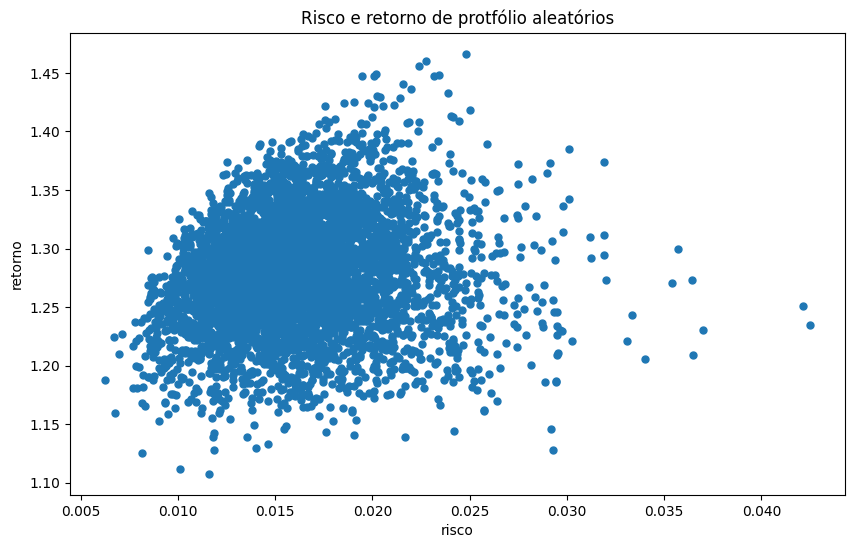

In [ ]:
import matplotlib.pyplot as pp

pp.figure( figsize = ( 10, 6 ) )
pp.plot( var, mu, 'o', markersize = 5)
pp.xlabel( 'risco' )
pp.ylabel( 'retorno' )
pp.title( 'Risco e retorno de protfólio aleatórios' )
pp.show()

### 2.2 A fronteira Eficiente

Observe que se conhecemos o retorno esperado desejado de $R$, podemos minimizar o risco utiliznado um problmea de otimização com a seguinte formulação

$$\Large
\begin{aligned}
& \min \quad \mathbf{x}^T C \mathbf{x} \\
& \text{s.a:} \quad \mathbf{r}^T \mathbf{x} = R \\
& \quad \quad \sum_{i=1}^{n} x_i = 1 \\
& \quad \quad x_i \geq 0 \quad \quad i \in \{1, 2, \dots, n\}
\end{aligned}
$$

A matriz de covari'ancia $C$ é simétrica semidefinida-positiva, portanto o problema acima é convexo. Iremos usar uma biblioteca para otimização convexa a fim de resolver este problema para diversos valores de $R$ que sabemos serem úteis.

In [ ]:
import cvxopt as opt

mus = np.linspace( 1.25, max( mu ), 30)




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 7.5 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
[-1.61e-01]
[-3.55e-01]

